In [1]:
import torch
from torch.nn import functional as F

import numpy as np
import voxeloo

from PIL import Image
from dataclasses import dataclass
from typing import Optional

In [2]:
points = np.stack(
    np.meshgrid(
        np.linspace(0, 512, 16),
        np.linspace(0, 512, 16),
    ),
    axis=-1,
)

In [3]:
points += 24.0 * np.random.random(points.shape)

### Plot the points as a voronoi diagram

In [4]:
def assignment_to_image(assignment, palette=None):
    image = voxeloo.voronoi.rasterize_2d(points.reshape(-1, 2).astype(int), (512, 512))
    if palette is None:
        palette = np.random.randint(0, 255, size=(assignment.max() + 1, 3), dtype=np.uint8)
    return Image.fromarray(palette[assignment[image]])

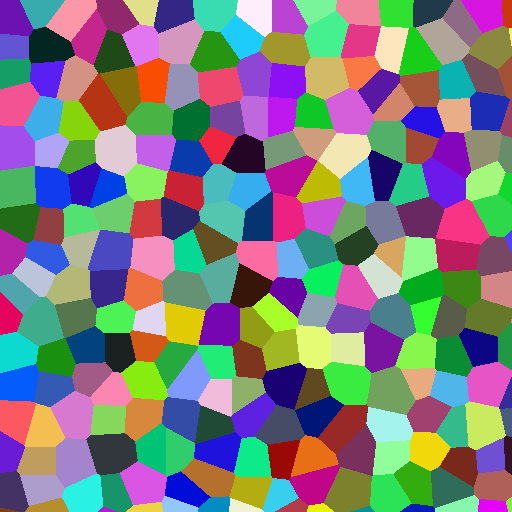

In [5]:
assignment_to_image(np.arange(16 * 16))

### Define the biomes 

In [6]:
@dataclass
class Biome:
    name: str
    rarity: float
    color: np.ndarray
    structure: Optional[str] = None

In [9]:
biomes = [
    Biome(
        name="common",
        rarity=0.6,
        color=np.array([50, 200, 100], np.uint8),
    ),
    Biome(
        name="mountain",
        rarity=0.2,
        structure="linear",
        color=np.array([200, 100, 100], np.uint8),
    ),
    Biome(
        name="forest",
        rarity=0.2,
        structure="blobby",
        color=np.array([20, 170, 50], np.uint8),
    ),
]

### Define some useful tensor operations

In [10]:
def normalize(tensor):
    return (tensor - tensor.min()) / (tensor.max() - tensor.min())

def conv(tensor, kernel, pad):
    assert kernel 
    b, c, h, w = tensor.shape
    kernel = torch.Tensor(kernel)
    kernel = kernel.to(tensor.device).expand(c, 1, *kernel.shape)
    return F.conv2d(F.pad(tensor, pad=pad, mode="replicate"), kernel, groups=c)

def edge(tensor):
    return conv(
        tensor,
        [
            [-1, -1, -1],
            [-1, 8, -1],
            [-1, -1, -1],
        ],
        (1, 1, 1, 1),
    ).abs()

def axial(tensor):
    a = conv(
        tensor,
        [
            [1, -1, 1],
            [1, 2, 1],
            [1, -1, 1],
        ],
        (1, 1, 1, 1),
    ).abs()
    b = conv(
        tensor,
        [
            [1, 1, 1],
            [-1, 2, -1],
            [1, 1, 1],
        ],
        (1, 1, 1, 1),
    ).abs()
    c = conv(
        tensor,
        [
            [1, -1, 1],
            [-1, 4, -1],
            [1, -1, 1],
        ],
        (1, 1, 1, 1),
    ).abs()
    return torch.minimum(torch.minimum(a, b), c)

### Define some useful visualization routines

In [11]:
def heatmap_to_image(heat):
    return Image.fromarray(np.uint8(heat * 255) , "L")

### Define some loss functions

In [12]:
def structure_loss(kind, heat):
    if kind == "blobby":
        return edge(normalize(heat)).mean()
    elif kind == "scattered":
        return -edge(normalize(heat)).mean()
    elif kind == "linear":
        return axial(normalize(heat)).mean()
    else:
        assert kind is None, f"Unknown structure type {kind}"
        return 0.0

### Define the biome assignment model

In [13]:
class Quantizer(torch.nn.Module):
    def __init__(self, dim, codes):
        super().__init__()
        self.keys = torch.nn.Conv2d(dim, codes, 1)

    def forward(self, x, temp, hard=False):
        return F.gumbel_softmax(self.keys(x), dim=1, tau=temp, hard=hard)

In [27]:
dim = 16

E = torch.nn.Parameter(torch.randn(1, dim, *points.shape[0:2]), requires_grad=True)
Q = Quantizer(dim, len(biomes))

In [28]:
optimizer = torch.optim.Adam(
    [E, *Q.parameters()],
    lr=1e-3,
    betas=(0.5, 0.9),
    amsgrad=True,
)

loss: 8.135562896728516, temp: 1.0


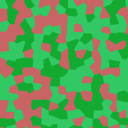

loss: 2.398162603378296, temp: 0.99


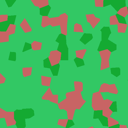

loss: 2.440654993057251, temp: 0.98


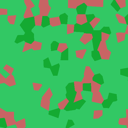

KeyboardInterrupt: 

In [29]:
num_steps = 100_000

for step in range(num_steps):
    optimizer.zero_grad()
    
    temp = max(0.1, 1.0 - step / num_steps)
    
    # Compute the biome assignment vector.
    prob = Q(E, temp=1.0)
    
    # Compute the loss.
    loss = 0
    for i, biome in enumerate(biomes):        
        i_prob = prob[:, i:i + 1, :, :]
        
        # Compute the rarity loss.
        loss += 10.0 * torch.abs(i_prob.mean() - biome.rarity) 
        
        # Compute a structural loss.
        loss += structure_loss(biome.structure, i_prob)
        
    # Update the assignment.
    loss.backward()
    optimizer.step()
    
    if step % 1000 == 0:
        print(f"loss: {loss.item()}, temp: {temp}")
        display(
            assignment_to_image(
                Q(E, temp=temp, hard=True).argmax(dim=1).cpu().numpy().flatten(),
                np.array([biome.color for biome in biomes])
            ).resize((128, 128))
        )

### Plot the biome assignment

In [ ]:
assignment = Q(E, temp=0.5, hard=True).argmax(dim=1)

In [ ]:
assignment_to_image(
    assignment.numpy().flatten(),
    np.array([biome.color for biome in biomes])
)

### TODO
1. Add losses for macro structure (e.g. blobby assignments vs sparse vs linear vs branchy)
2. We can think of the output as a heatmap for each biome type.
3. The losses are qualities of this heatmap structure.
4. How to test whether a heat map is "blobby" or "sparse" or "linear" or "branchy" ?
5. Need to map a heat map onto a "blobbiness" score... 
6. Crazy idea: Train a discriminator over sample images of each structural type. 

## Height Maps

### Naive solution

1. Generate some canonical noise map for each biome type.
2. Composite the various noise maps together.

#### Problems
1. Need to solve boundary conditions across biomes (e.g. mountains taller than neighoring grass tiles).
2. Want global variation in overall height (e.g. some base continental height).


### Optimization solution

1. Train a conv-net that generates a height value at each pixel.
2. The input to the conv-net is a 2D tensor of (embeddings, noise) for each tile.
3. The receptive field is some fixed number (so we can parallelize generation). 
4. We want the output to be continuous / smooth in some way that is biome dependent.
5. There should be some neighborhood conditions (e.g. relative heights over neighbors).
6. Perhaps we learn an assignment of perlin noise components at each location?
7. Maybe one of the losses tries to approximate the strength of each frequency?